In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matlab.engine

from sys import path
path.append('../../')
import wavelet_funcs as wf

In [2]:
eng = matlab.engine.start_matlab()

In [65]:
nt = 2048

dt = 0.5
Fs = 1/dt
t = np.arange(nt)*dt

fsignal = 0.03
x = np.cos(2*np.pi*fsignal*t)

## For checking COIs
# x = np.zeros(t.size)
# x[0] = 1
# x[-1] = 1

In [51]:
# Convert numpy array to MATLAB column vector
x_mat = matlab.double(x.astype(float).reshape(-1, 1).tolist())

eng.workspace["x"] = x_mat
eng.workspace["Fs"] = float(Fs)

eng.eval(
"""
[cfs,f,coi] = cwt(x,Fs,...
    'TimeBandwidth',15, ...
    'FrequencyLimits', [0.007, 0.1],...
    'Boundary', 'zeropad');
amp = abs(cfs);
""",
nargout=0)

amp = np.array(eng.workspace["amp"])
freq = np.array(eng.workspace["f"]).squeeze()
coi  = np.array(eng.workspace["coi"]).squeeze()

print(amp.shape)

(39, 2048)


Text(0.5, 1.0, 'Morse CWT Amplitude (TimeBandwidth=15)')

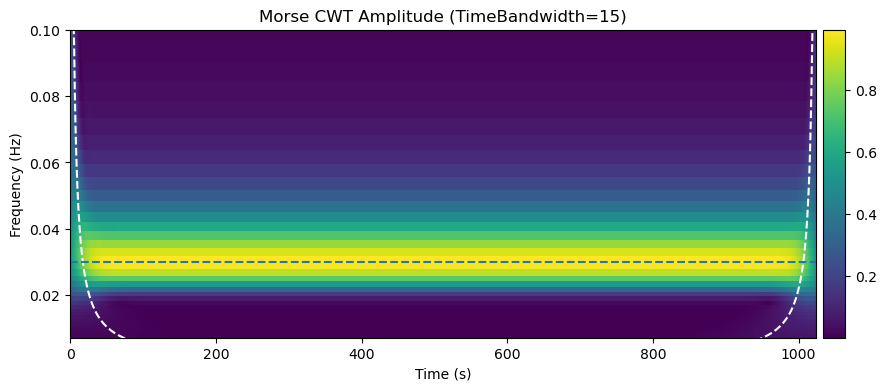

In [75]:
f, ax = wf.plot_cwt(amp, freq, t, add_colorbar=True)
ax.plot(t, coi, color='w', ls='--')
ax.set_ylim([freq.min(), freq.max()])
ax.axhline(fsignal, ls='--')
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("Morse CWT Amplitude (TimeBandwidth=15)")

In [77]:
eng.quit()